In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

In [29]:
exam_result_folder = Path("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Grading/2025-02_Exam/")
exam_result_path = Path("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Grading/2025-02_Exam/1740562243__0__tst__results_118505.xlsx")

In [3]:
exam_results = pd.read_excel(exam_result_path)
exam_results.dropna(subset=["Login"],inplace=True, how="all")
exam_results.head()

,Name,Login,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,...,07_Git,08_Peer_Review,09_OptimizedFundingCycle,09_PeerReview,11_ScientificPractice,12_ScholarlyLiterature,12_LiteraturManagement,02_Matching_Definitions,07_Basics,03_Design-Plan
0,"Alam, Md. Iftekharul",ho59vuge,1,1,70.5,75,passed,36,36,100%,...,2,1.5,1.5,2,2,2,2,5,3,3
1,"Aqeel, Hafsa",ip14obek,1,1,68.5,75,passed,36,36,100%,...,2,1.5,1.5,2,2,2,2,5,2,3
2,"Ashikuzzaman, Md",bo92qejy,1,1,71.5,75,passed,36,36,100%,...,2,1.5,1.5,2,2,2,2,5,3,3
3,"Assan Mohamed, Abrar",ho19tuje,1,1,68.0,75,passed,36,36,100%,...,2,1.5,1.5,2,2,2,2,3,3,3
4,"Azhar, Dua",be44xoqi,1,1,68.0,75,passed,36,36,100%,...,2,1.5,1.5,2,2,2,2,5,3,3


In [4]:
exam_results.set_index("Login", inplace=True)
exam_results.index.names = ["student_id"]
exam_results.head()

,Name,Started Passes,Scored Pass,Test Results in Points,Maximum Available Points,Test Results in Marks,Questions already worked through,Total number of Questions,Percent of total workload already worked through,Time of Work,...,07_Git,08_Peer_Review,09_OptimizedFundingCycle,09_PeerReview,11_ScientificPractice,12_ScholarlyLiterature,12_LiteraturManagement,02_Matching_Definitions,07_Basics,03_Design-Plan
student_id,,,,,,,,,,,,,,,,,,,,,
ho59vuge,"Alam, Md. Iftekharul",1,1,70.5,75,passed,36,36,100%,00:42:31,...,2,1.5,1.5,2,2,2,2,5,3,3
ip14obek,"Aqeel, Hafsa",1,1,68.5,75,passed,36,36,100%,00:48:19,...,2,1.5,1.5,2,2,2,2,5,2,3
bo92qejy,"Ashikuzzaman, Md",1,1,71.5,75,passed,36,36,100%,00:27:09,...,2,1.5,1.5,2,2,2,2,5,3,3
ho19tuje,"Assan Mohamed, Abrar",1,1,68.0,75,passed,36,36,100%,00:30:53,...,2,1.5,1.5,2,2,2,2,3,3,3
be44xoqi,"Azhar, Dua",1,1,68.0,75,passed,36,36,100%,00:41:39,...,2,1.5,1.5,2,2,2,2,5,3,3


<Axes: >

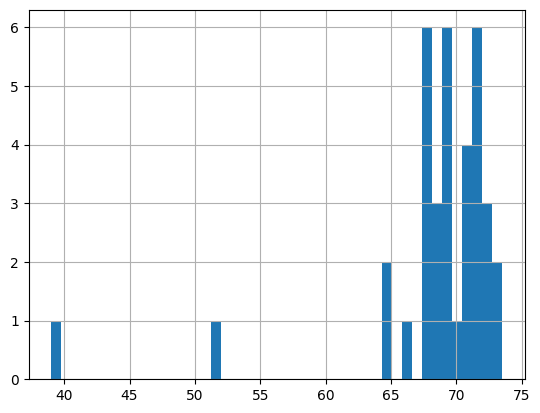

In [5]:
points = exam_results["Test Results in Points"]
points.hist(bins=45)

In [6]:
points = pd.DataFrame(points)
points.columns = ["points"]
points.head()

,points
student_id,
ho59vuge,70.5
ip14obek,68.5
bo92qejy,71.5
ho19tuje,68.0
be44xoqi,68.0


In [13]:
pass_score = 45.0
max_score = 75.0
bin_size = round((max_score-pass_score) / 11, 1)
bin_size

2.7

In [14]:
grades = [1.0, 1.33, 1.66, 2.0, 2.33, 2.66, 3.0, 3.33, 3.66, 4.0, 4.33, 5.0]
grades = grades[::-1]

In [15]:
min_points = [pass_score + bin_size * i for i in range(-2,len(grades)-1)]
min_points

[39.6,
 42.3,
 45.0,
 47.7,
 50.4,
 53.1,
 55.8,
 58.5,
 61.2,
 63.900000000000006,
 66.6,
 69.3,
 72.0]

In [16]:
grade_map = pd.DataFrame(zip(min_points, grades), columns=["min_points", "grade"])
grade_map["max_points"] = grade_map["min_points"] + bin_size - 0.1
grade_map.set_index("grade", inplace=True)
grade_map.loc[1.0, "max_points"] = max_score
grade_map.loc[5.0, "min_points"] = 0.0

grade_map.sort_index(inplace=True)

grade_map

,min_points,max_points
grade,,
1.00,69.3,75.0
1.33,66.6,69.2
1.66,63.9,66.5
2.00,61.2,63.8
2.33,58.5,61.1
2.66,55.8,58.4
3.00,53.1,55.7
3.33,50.4,53.0
3.66,47.7,50.3


In [17]:
# return the value of the index of grade_map where points is between min_points and max_points
points["grade"] = [grade_map[(grade_map["min_points"] <= point) & (grade_map["max_points"] >= point)].index[0] for point in points["points"]]
points


,points,grade
student_id,,
ho59vuge,70.5,1.00
ip14obek,68.5,1.33
bo92qejy,71.5,1.00
ho19tuje,68.0,1.33
be44xoqi,68.0,1.33
ig39amoq,52.0,3.33
ny43hobe,70.0,1.00
yw39anyn,71.0,1.00
hi28lufu,68.0,1.33


<Axes: >

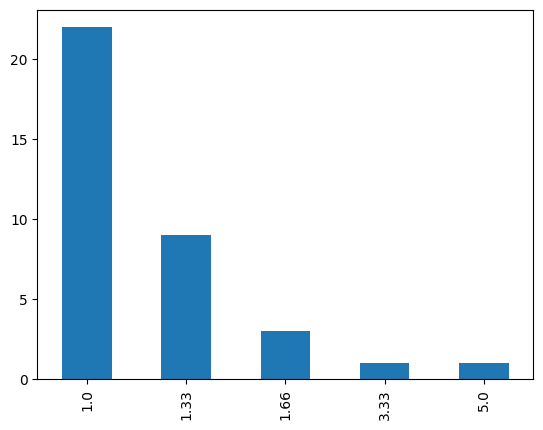

In [18]:
# Without Bonus

points["grade"].value_counts().sort_index().plot(kind="bar")

In [19]:
points["grade"].describe()

count    36.000000
mean      1.313333
std       0.759349
min       1.000000
25%       1.000000
50%       1.000000
75%       1.330000
max       5.000000
Name: grade, dtype: float64

In [20]:
bonus_points = pd.read_excel("/Users/abelluc/FAUbox/DigiKolleg/BPOS/Exercise/WS24_25_Results/result_final.xlsx")
#rename column idm to identifier 
bonus_points.rename(columns={"idm":"student_id"}, inplace=True)
bonus_points.set_index("student_id", inplace=True)
bonus_points

,passed,bonus
student_id,,
ab61yxuh,1,0.00
am59ybos,4,0.00
as43akuw,1,0.00
ce32dosa,2,0.00
co07duri,1,0.00
cy73sela,5,0.33
du68hazy,6,0.66
dy81qeky,6,0.66
ex22ahog,3,0.00


In [21]:
# join dataframes
points = points.join(bonus_points, how="left")
points.fillna(0, inplace=True)

#points.drop("student_id", axis=1, inplace=True)
points

,points,grade,passed,bonus
student_id,,,,
ho59vuge,70.5,1.00,0.0,0.00
ip14obek,68.5,1.33,0.0,0.00
bo92qejy,71.5,1.00,0.0,0.00
ho19tuje,68.0,1.33,0.0,0.00
be44xoqi,68.0,1.33,0.0,0.00
ig39amoq,52.0,3.33,5.0,0.33
ny43hobe,70.0,1.00,0.0,0.00
yw39anyn,71.0,1.00,6.0,0.66
hi28lufu,68.0,1.33,1.0,0.00


In [22]:
points.drop("passed", axis=1, inplace=True)

In [23]:
points

,points,grade,bonus
student_id,,,
ho59vuge,70.5,1.00,0.00
ip14obek,68.5,1.33,0.00
bo92qejy,71.5,1.00,0.00
ho19tuje,68.0,1.33,0.00
be44xoqi,68.0,1.33,0.00
ig39amoq,52.0,3.33,0.33
ny43hobe,70.0,1.00,0.00
yw39anyn,71.0,1.00,0.66
hi28lufu,68.0,1.33,0.00


In [24]:
points["grade_with_bonus"] = points["grade"] - points["bonus"]

# set grade_with_bonus to 1.0 if grade_with_bonus is smaller than 1.0
points["grade_with_bonus"][points["grade_with_bonus"] < 1.0] = 1.0

# set grade_with_bonus to grade value if grade is greater than 4.0
points["grade_with_bonus"][points["grade"] > 4.0] = points["grade"]

points

,points,grade,bonus,grade_with_bonus
student_id,,,,
ho59vuge,70.5,1.00,0.00,1.00
ip14obek,68.5,1.33,0.00,1.33
bo92qejy,71.5,1.00,0.00,1.00
ho19tuje,68.0,1.33,0.00,1.33
be44xoqi,68.0,1.33,0.00,1.33
ig39amoq,52.0,3.33,0.33,3.00
ny43hobe,70.0,1.00,0.00,1.00
yw39anyn,71.0,1.00,0.66,1.00
hi28lufu,68.0,1.33,0.00,1.33


In [25]:
points = round(points, 1)
points.sort_values("grade", inplace=True)
points

,points,grade,bonus,grade_with_bonus
student_id,,,,
ho59vuge,70.5,1.0,0.0,1.0
ra22dahe,69.5,1.0,0.0,1.0
up26aqyc,72.5,1.0,0.0,1.0
qa35wabo,69.5,1.0,0.0,1.0
we90xamu,69.5,1.0,0.0,1.0
ke05zymu,72.5,1.0,0.0,1.0
iv90emef,71.5,1.0,0.3,1.0
de83tafy,69.5,1.0,0.0,1.0
ry59dame,71.5,1.0,0.0,1.0


In [26]:
points.describe()

,points,grade,bonus,grade_with_bonus
count,36.000000,36.000000,36.000000,36.000000
mean,68.402778,1.308333,0.111111,1.283333
std,6.221873,0.758711,0.231489,0.740849
min,39.000000,1.000000,0.000000,1.000000
25%,68.000000,1.000000,0.000000,1.000000
50%,69.500000,1.000000,0.000000,1.000000
75%,71.500000,1.300000,0.000000,1.300000
max,73.500000,5.000000,0.700000,5.000000


<Axes: >

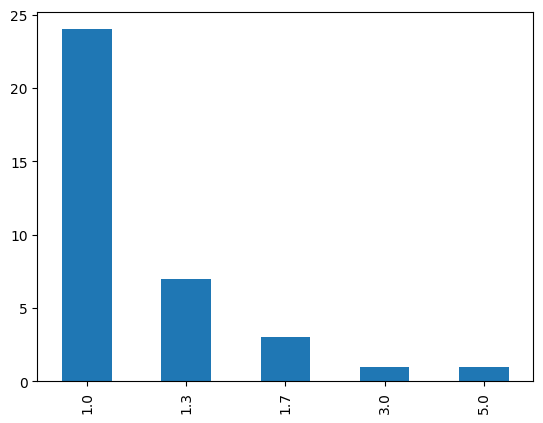

In [27]:
points["grade_with_bonus"].value_counts().sort_index().plot(kind="bar")

In [30]:
# save to csv
points.to_csv(exam_result_folder.joinpath("2025-02_BPOS_Exam_results_final.csv"))